# Phase 10 — blind bounded global moduli search

This notebook reproduces the Phase-10 result. The three optimizers saw only $\ell^2$ and started from the canonical product metric $\mathrm{diag}(D,D)$. CM and passive-gate metadata were revealed only after all 5,760 queries finished.

In [1]:
from pathlib import Path
import gzip, json, os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/gkp_phase10_mpl')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
CANDIDATES = (HERE, HERE.parent, HERE / 'passive-cliffords')
ROOT = next(path for path in CANDIDATES if (path / 'src' / 'gkp_passive_cliffords').exists())
DATA = ROOT / 'data'
FIGURES = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)
def load_json(name):
    path = DATA / name
    if path.exists(): return json.loads(path.read_text())
    with gzip.open(str(path) + '.gz', 'rt') as handle: return json.load(handle)
summary = pd.DataFrame(load_json('phase10_blind_search_summary.json'))
evaluations = pd.DataFrame(load_json('phase10_blind_search_evaluations.json'))
comparison = pd.DataFrame(load_json('phase10_posthoc_cm_comparison.json'))
audit = pd.DataFrame(load_json('phase10_high_precision_audit.json'))
known_cm = pd.DataFrame(load_json('strongest_known_cm_records.json'))
for frame in (summary, evaluations, comparison, audit, known_cm):
    frame['type'] = frame['polarization_type'].map(lambda x: '(' + ','.join(map(str, x)) + ')')
known_by_type = known_cm.set_index('type')['ell_squared_numeric']
comparison['strongest_known_cm_ell_squared'] = comparison['type'].map(known_by_type)
comparison['blind_to_strongest_known_cm_ratio'] = comparison['best_blind_ell_squared'] / comparison['strongest_known_cm_ell_squared']
len(summary), len(evaluations), len(comparison), len(audit)

(60, 5760, 20, 60)

## Protocol checks

There are 20 fixed $(D,R)$ searches, three methods per search, and 96 calls per method. The radius is the RMS affine-invariant distance from the canonical product metric.

In [2]:
assert len(summary) == 5 * 4 * 3
assert len(evaluations) == 5 * 4 * 3 * 96
assert set(summary['budget']) == {96}
assert evaluations.groupby(['type', 'radius', 'method']).size().eq(96).all()
max_overrun = (evaluations['achieved_rms_distance'] - evaluations['radius']).max()
max_audit_error = audit['ell_absolute_discrepancy'].max()
pd.Series({'objective evaluations': len(evaluations), 'maximum radius overrun': max_overrun, 'maximum 70-digit audit discrepancy': max_audit_error})

objective evaluations                 5.760000e+03
maximum radius overrun                6.661338e-15
maximum 70-digit audit discrepancy    2.220446e-16
dtype: float64

## Headline comparison

The table shows the strongest blind endpoint at the largest preregistered radius and compares it with the strongest exact CM record currently known in the repository. The frozen protocol ledger separately retains its original Phase-5-population comparison.

In [3]:
largest = comparison[comparison['radius'].eq(1.5)].copy()
largest[['type', 'best_method', 'best_blind_ell_squared', 'strongest_known_cm_ell_squared', 'blind_to_strongest_known_cm_ratio', 'blind_beats_cm']].sort_values('type').style.format({'best_blind_ell_squared': '{:.9f}', 'strongest_known_cm_ell_squared': '{:.9f}', 'blind_to_strongest_known_cm_ratio': '{:.3%}'})

,type,best_method,best_blind_ell_squared,strongest_known_cm_ell_squared,blind_to_strongest_known_cm_ratio,blind_beats_cm
3,"(1,1,2)",cma_es,0.869062246,1.154700538,75.263%,False
7,"(1,1,3)",bayesian_ucb,0.777729500,1.154700538,67.353%,False
11,"(1,2,2)",bayesian_ucb,0.735414635,1.000000000,73.541%,False
15,"(1,3)",bayesian_ucb,0.730917844,0.816496581,89.519%,False
19,"(1,5)",cma_es,0.470379128,0.632455532,74.373%,False


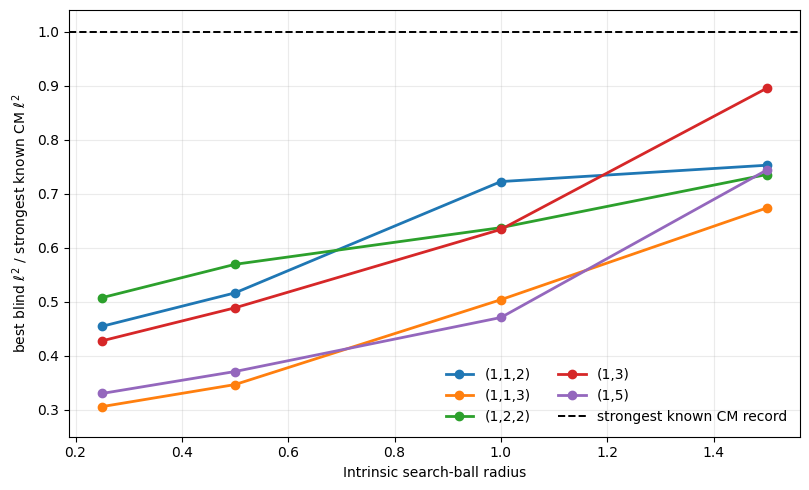

In [4]:
fig, ax = plt.subplots(figsize=(8.2, 5.0))
for label, group in comparison.sort_values('radius').groupby('type'):
    ax.plot(group['radius'], group['blind_to_strongest_known_cm_ratio'], marker='o', linewidth=2, label=label)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.4, label='strongest known CM record')
ax.set(xlabel='Intrinsic search-ball radius', ylabel=r'best blind $\ell^2$ / strongest known CM $\ell^2$', ylim=(0.25, 1.04))
ax.grid(alpha=.25)
ax.legend(ncol=2, frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / 'phase10_blind_to_cm_ratio.png', dpi=180)
plt.show()

Every curve rises with the allowed radius, but none reaches the CM line. The fact that the radius-1.5 winners are generally near the boundary motivates a later expanding-ball continuation; it does not invalidate this frozen bounded comparison.

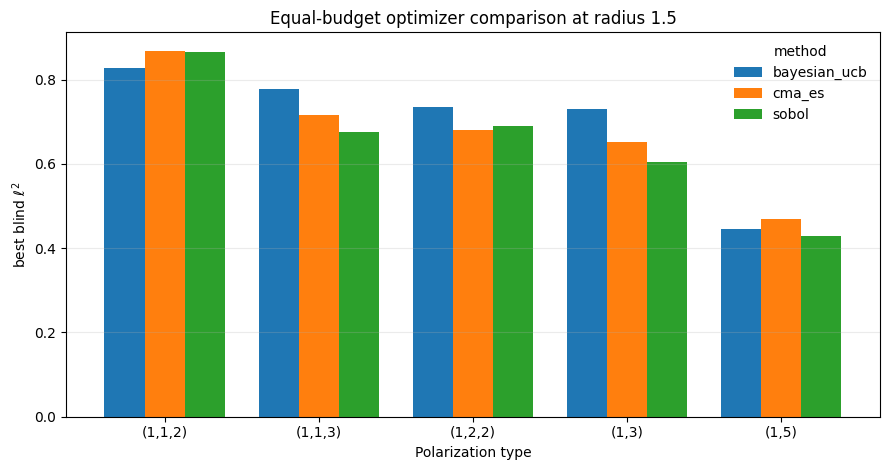

best_method
cma_es          10
bayesian_ucb     9
sobol            1
Name: count, dtype: int64

In [5]:
method15 = summary[summary['radius'].eq(1.5)].pivot(index='type', columns='method', values='best_ell_squared')
method15 = method15.loc[sorted(method15.index)]
ax = method15.plot(kind='bar', figsize=(9, 4.8), width=.78)
ax.set(xlabel='Polarization type', ylabel=r'best blind $\ell^2$', title='Equal-budget optimizer comparison at radius 1.5')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=.25)
ax.legend(title='method', frameon=False)
plt.tight_layout()
plt.savefig(FIGURES / 'phase10_method_comparison.png', dpi=180)
plt.show()
comparison['best_method'].value_counts()

CMA-ES wins 10 of the 20 comparisons, Bayesian UCB wins 9, and Sobol wins 1. The CM conclusion therefore does not rest on one search heuristic.

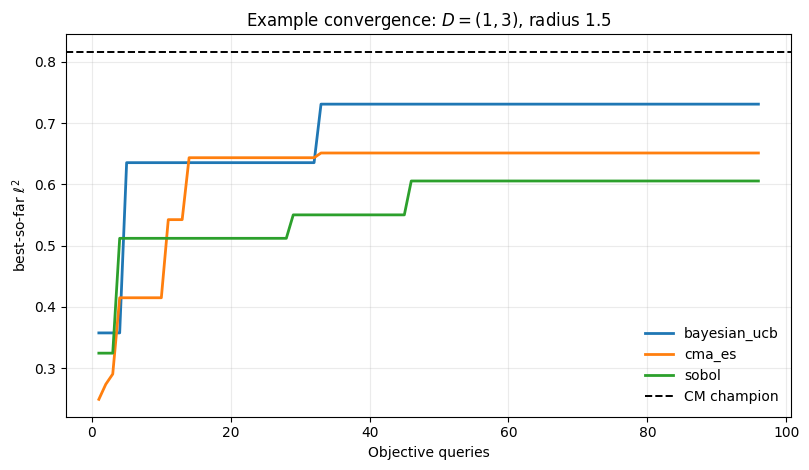

In [6]:
example = evaluations[(evaluations['type'].eq('(1,3)')) & evaluations['radius'].eq(1.5)].copy()
fig, ax = plt.subplots(figsize=(8.2, 4.8))
for method, group in example.groupby('method'):
    group = group.sort_values('query')
    ax.plot(np.arange(1, len(group) + 1), np.maximum.accumulate(group['ell_squared']), label=method, linewidth=2)
cm_value = known_by_type['(1,3)']
ax.axhline(cm_value, color='black', linestyle='--', linewidth=1.4, label='CM champion')
ax.set(xlabel='Objective queries', ylabel=r'best-so-far $\ell^2$', title=r'Example convergence: $D=(1,3)$, radius $1.5$')
ax.grid(alpha=.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / 'phase10_example_convergence.png', dpi=180)
plt.show()

## Interpretation

The blind search is a stronger control than perturbing a CM point: it starts from data determined only by the polarization type and explores all compatible directions. Within the frozen balls and budgets, the strongest exact CM records currently known in the repository remain decisively ahead. This supports—but does not prove—the conjecture that arithmetic special points are enriched near high-$\ell$ regions.

In [7]:
assert not comparison['blind_beats_cm'].any()
assert comparison['blind_to_strongest_known_cm_ratio'].max() < 1.0
assert max_audit_error < 2e-12
assert max_overrun < 2e-9
print('All Phase-10 notebook checks passed.')

All Phase-10 notebook checks passed.
